LABEL VERIFICATION
  ✅ 'Not Suicide post' → Low (expected Low)
  ✅ 'non-suicide' → Low (expected Low)
  ✅ 'normal' → Low (expected Low)
  ✅ 'good morning everyone' → Low (expected Low)
  ✅ 'making some lunch' → Low (expected Low)
  ❌ 'feeling anxious' → Low (expected Moderate)
  ✅ 'struggling with depression' → Moderate (expected Moderate)
  ✅ 'Potential Suicide post' → High (expected High)
  ✅ 'suicidal thoughts' → High (expected High)
  ❌ 'i want to end my life' → Low (expected High)
❌ LABELS STILL WRONG — do not train yet!

📂 Suicide_Ideation_Dataset(Twitter-based).csv — 1787 rows
  Labels → Low(0):1127  Moderate(1):0  High(2):660

📂 dataset_part1.csv — 116037 rows
  Labels → Low(0):57938  Moderate(1):0  High(2):58099

📂 dataset_part2.csv — 116037 rows
  Labels → Low(0):58099  Moderate(1):0  High(2):57938

📂 mental_health_combined_test.csv — 992 rows
  Labels → Low(0):248  Moderate(1):496  High(2):248

📂 mental_heath_feature_engineered.csv — 49612 rows
  Labels → Low(0):18391  Moder

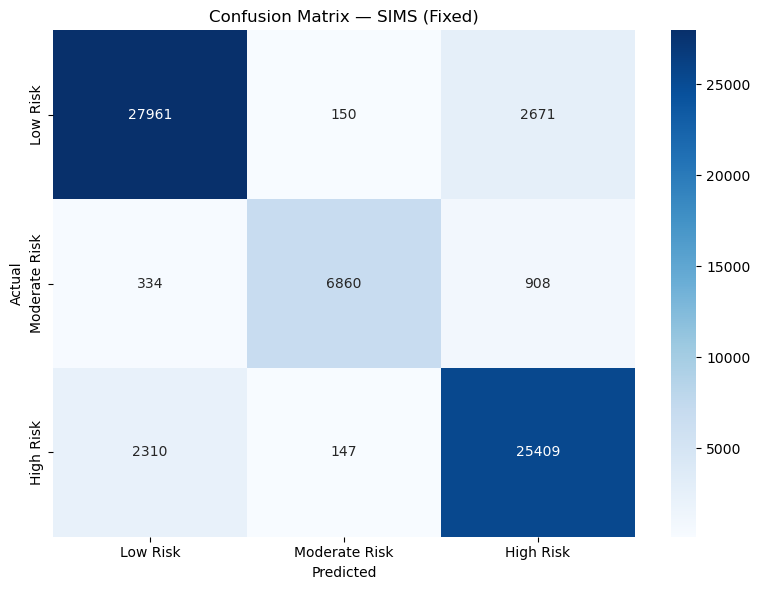


REAL SENTENCE TEST
  ✅ 'good morning everyone' → Low Risk
  ✅ 'making lunch today' → Low Risk
  ✅ 'time for some coffee' → Low Risk
  ✅ 'feeling really anxious' → Moderate Risk
  ✅ 'struggling with depression' → Moderate Risk
  ✅ 'i want to end my life' → High Risk
  ✅ 'i dont want to live anymore' → High Risk
  ✅ 'thinking about suicide' → High Risk

✅ Model saved! Ready for dashboard.


In [2]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import joblib
import os
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STEP 0: DELETE OLD CORRUPTED PKL FILES
# ============================================================
for f in ['sims_pipeline.pkl', 'sims_tfidf_vectorizer.pkl', 'sims_classifier.pkl']:
    if os.path.exists(f):
        os.remove(f)
        print(f"🗑️ Deleted: {f}")

# ============================================================
# STEP 1: NLTK DOWNLOADS
# ============================================================
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

CONTRACTIONS = {
    "can't": "cannot", "won't": "will not", "n't": " not",
    "i'm": "i am", "it's": "it is", "i've": "i have",
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "i'll": "i will", "you're": "you are", "they're": "they are",
    "i'd": "i would", "that's": "that is", "he's": "he is",
    "she's": "she is", "we're": "we are", "couldn't": "could not",
    "wouldn't": "would not", "shouldn't": "should not"
}

# ============================================================
# STEP 2: PREPROCESSING
# ============================================================
def clean_and_preprocess(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    text = re.sub(r'http\S+|www\S+|\@\w+', '', text)
    text = re.sub(r'\d+', '', text)
    tokens = word_tokenize(text)
    processed = []
    for w in tokens:
        if w not in stop_words:
            if any(ord(char) > 127 for char in w) or w.isalnum():
                processed.append(lemmatizer.lemmatize(w))
    return " ".join(processed)

# ============================================================
# STEP 3: FIXED LABEL MAPPING ✅
# ============================================================
def map_risk_labels(status):
    status = str(status).lower().strip()
    
    # ✅ NEGATION FIRST — critical fix
    if any(x in status for x in [
        'not suicide', 'non-suicide', 'non suicide',
        'normal', 'no risk', 'no ideation', 'not suicidal', 'negative'
    ]):
        return 0  # Low Risk

    if any(x in status for x in ['suicide', 'suicidal', 'high']):
        return 2  # High Risk

    if any(x in status for x in ['anxiety', 'stress', 'depression', 'moderate', 'medium']):
        return 1  # Moderate Risk

    return 0  # Default Low Risk

# ============================================================
# STEP 4: VERIFY LABELS BEFORE TRAINING
# ============================================================
print("=" * 50)
print("LABEL VERIFICATION")
print("=" * 50)

checks = [
    ("Not Suicide post",          0),
    ("non-suicide",               0),
    ("normal",                    0),
    ("good morning everyone",     0),
    ("making some lunch",         0),
    ("feeling anxious",           1),
    ("struggling with depression",1),
    ("Potential Suicide post",    2),
    ("suicidal thoughts",         2),
    ("i want to end my life",     2),
]

names = {0: "Low", 1: "Moderate", 2: "High"}
all_ok = True

for text, expected in checks:
    result = map_risk_labels(text)
    ok = result == expected
    if not ok: all_ok = False
    print(f"  {'✅' if ok else '❌'} '{text}' → {names[result]} (expected {names[expected]})")

print("=" * 50)
if all_ok:
    print("✅ ALL LABELS CORRECT — proceeding to training")
else:
    print("❌ LABELS STILL WRONG — do not train yet!")

# ============================================================
# STEP 5: LOAD DATASETS
# ============================================================
def load_all_datasets():
    files = [
        'Suicide_Ideation_Dataset(Twitter-based).csv',
        'dataset_part1.csv',
        'dataset_part2.csv',
        'mental_health_combined_test.csv',
        'mental_heath_feature_engineered.csv',
        'mental_heath_unbanlanced.csv'
    ]

    TEXT_COLS  = ['text', 'tweet', 'Tweet', 'post', 'content']
    LABEL_COLS = ['label', 'status', 'class', 'Suicide', 'risk', 'Label']

    frames = []
    for f in files:
        if not os.path.exists(f):
            continue
        df = pd.read_csv(f)
        print(f"\n📂 {f} — {len(df)} rows")

        text_col  = next((c for c in TEXT_COLS  if c in df.columns), None)
        label_col = next((c for c in LABEL_COLS if c in df.columns), None)

        if not text_col or not label_col:
            print(f"  ⚠️ Skipped — columns not found")
            continue

        df = df[[text_col, label_col]].rename(
            columns={text_col: 'text', label_col: 'raw_label'}
        )
        df['label'] = df['raw_label'].apply(map_risk_labels)

        dist = df['label'].value_counts().sort_index().to_dict()
        print(f"  Labels → Low(0):{dist.get(0,0)}  Moderate(1):{dist.get(1,0)}  High(2):{dist.get(2,0)}")
        frames.append(df[['text', 'label']])

    if not frames:
        raise FileNotFoundError("No datasets found.")

    combined = pd.concat(frames, ignore_index=True)
    print(f"\n✅ Total combined: {len(combined)} rows")

    print("🔄 Preprocessing text...")
    combined['preprocessed_text'] = combined['text'].apply(clean_and_preprocess)
    combined[['text', 'preprocessed_text', 'label']].head(200).to_csv(
        'preprocessed_sample_hf.csv', index=False
    )
    return combined

# ============================================================
# STEP 6: TRAIN MODEL
# ============================================================
def train_high_fidelity_model():
    df = load_all_datasets()
    df = df[df['preprocessed_text'].str.strip() != ""].dropna(subset=['preprocessed_text'])

    X_train, X_test, y_train, y_test = train_test_split(
        df['preprocessed_text'], df['label'],
        test_size=0.2, random_state=42, stratify=df['label']
    )

    print(f"\nTraining: {len(X_train)} | Testing: {len(X_test)}")

    sims_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1, 3), sublinear_tf=True)),
        ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42))
    ])

    print("🔄 Training... (may take a few minutes)")
    sims_pipeline.fit(X_train, y_train)

    # Evaluate
    predictions = sims_pipeline.predict(X_test)
    print("\n" + "="*50)
    print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}")
    print(classification_report(y_test, predictions,
          target_names=['Low Risk', 'Moderate Risk', 'High Risk']))

    # Confusion matrix
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low Risk', 'Moderate Risk', 'High Risk'],
                yticklabels=['Low Risk', 'Moderate Risk', 'High Risk'])
    plt.title('Confusion Matrix — SIMS (Fixed)')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    plt.show()

    # ============================================================
    # STEP 7: REAL SENTENCE TEST
    # ============================================================
    print("\n" + "="*50)
    print("REAL SENTENCE TEST")
    print("="*50)
    label_map = {0: 'Low Risk', 1: 'Moderate Risk', 2: 'High Risk'}
    tests = [
        ("good morning everyone",          "Low Risk"),
        ("making lunch today",             "Low Risk"),
        ("time for some coffee",           "Low Risk"),
        ("feeling really anxious",         "Moderate Risk"),
        ("struggling with depression",     "Moderate Risk"),
        ("i want to end my life",          "High Risk"),
        ("i dont want to live anymore",    "High Risk"),
        ("thinking about suicide",         "High Risk"),
    ]
    for sentence, expected in tests:
        result = label_map[sims_pipeline.predict([clean_and_preprocess(sentence)])[0]]
        print(f"  {'✅' if result == expected else '❌'} '{sentence}' → {result}")

    # Save
    joblib.dump(sims_pipeline, 'sims_pipeline.pkl')
    joblib.dump(sims_pipeline.named_steps['tfidf'], 'sims_tfidf_vectorizer.pkl')
    joblib.dump(sims_pipeline.named_steps['classifier'], 'sims_classifier.pkl')
    print("\n✅ Model saved! Ready for dashboard.")

train_high_fidelity_model()

In [2]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# Load your pipeline
pipeline = joblib.load('sims_pipeline.pkl')

# Load dataset
df = pd.read_csv('Suicide_Ideation_Dataset(Twitter-based).csv')

# Auto detect columns
text_col  = next((c for c in ['text','tweet','Tweet'] if c in df.columns), None)
label_col = next((c for c in ['label','status','Suicide','class'] if c in df.columns), None)

# Fixed label mapping
def map_risk_labels(status):
    status = str(status).lower().strip()
    if any(x in status for x in ['not suicide','non-suicide','normal','no risk']):
        return 0
    if any(x in status for x in ['suicide','suicidal','high']):
        return 2
    if any(x in status for x in ['anxiety','stress','depression','moderate','medium']):
        return 1
    return 0

df['label'] = df[label_col].apply(map_risk_labels)
df = df[df[text_col].notna()]

# Check what classes actually exist
print("Classes found:", sorted(df['label'].unique()))
print("Label distribution:")
print(df['label'].value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    df[text_col], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

predictions = pipeline.predict(X_test)

# Auto-build target names from actual classes only
label_map   = {0: 'Low Risk', 1: 'Moderate Risk', 2: 'High Risk'}
actual_labels      = sorted(df['label'].unique())
actual_label_names = [label_map[l] for l in actual_labels]

print("\n" + "="*50)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}")
print("="*50)
print(classification_report(
    y_test, predictions,
    labels=actual_labels,
    target_names=actual_label_names
))

Classes found: [np.int64(0), np.int64(2)]
Label distribution:
label
0    1126
2     659
Name: count, dtype: int64

Accuracy: 96.08%
              precision    recall  f1-score   support

    Low Risk       0.96      0.98      0.97       225
   High Risk       0.97      0.92      0.95       132

    accuracy                           0.96       357
   macro avg       0.96      0.95      0.96       357
weighted avg       0.96      0.96      0.96       357

